## **Import Required Libraries**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

## **Load Dataset**

In [20]:
df = pd.read_csv("spam.csv", encoding="latin-1")

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## **Data Cleaning**

In [21]:
df = pd.read_csv("spam.csv", encoding="latin-1")
df = df[['v1','v2']]
df.columns = ['label','message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## **Convert Labels to Numbers**

In [22]:
df['label'] = df['label'].map({'ham':0, 'spam':1})

## **Data Visualization**

Spam vs Non-Spam Distribution

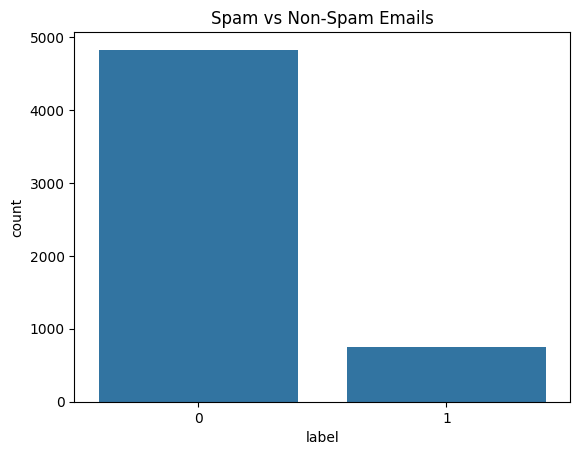

In [23]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Non-Spam Emails")
plt.show()

## **Convert Text to Numbers**

Use CountVectorizer.


In [24]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['message'])

y = df['label']

## **Train-Test Split**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **Train Machine Learning Model**

Naive Bayes works best for spam detection.

In [26]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

## **Make Predictions**

In [27]:
predictions = model.predict(X_test)

## **Model Evaluation**

In [28]:
print("Accuracy:", accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions))

Accuracy: 0.97847533632287
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.91      0.93      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.96      0.95      1115
weighted avg       0.98      0.98      0.98      1115



**Test with Custom Email**

In [30]:
sample = ["Congratulations! You have won a free lottery ticket"]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Spam Email")
else:
    print("Not Spam")

Spam Email


## **Conclusion**

A machine learning model was developed to classify emails as spam or non-spam using the Naive Bayes algorithm. Text messages were converted into numerical features using CountVectorizer, and the model achieved high accuracy in detecting spam emails.